# Exploratory Data Analysis (EDA)
## 02 — Memahami Pola Air Tanah dan Cuaca

**Proyek:** Prediksi Muka Air Tanah Satu Minggu ke Depan · **Studi kasus:** Drenthe, Belanda · **Penyusun:** Rasen

Pada notebook sebelumnya, saya sudah menetapkan masalah proyek dan menyiapkan data mingguan. Saya menemukan bahwa data air tanah memiliki beberapa celah pengamatan. Karena itu, minggu yang tidak layak tetap disimpan dalam kalender, tetapi nilai head-nya dibiarkan kosong.

Sekarang saya ingin memahami pola yang ada sebelum membuat fitur dan melatih model. Pertanyaan utamanya adalah: apakah riwayat air tanah dan cuaca menyediakan informasi yang masuk akal untuk memperkirakan kondisi minggu berikutnya?

Notebook ini membahas pembagian periode, kelengkapan data pengembangan, grafik waktu, distribusi, pola musiman, korelasi, dan hubungan dengan jeda waktu. Hasilnya berupa temuan eksploratif serta kandidat fitur, belum berupa model terbaik.

### Cara menggunakan notebook

1. Simpan sebagai `notebooks/02_eda.ipynb` di proyek `groundwater_forecasting`.
2. Jalankan `01_data_understanding.ipynb` terlebih dahulu sampai file `data/processed/netherlands_weekly.csv` terbentuk.
3. Gunakan kernel yang sama seperti sebelumnya, lalu jalankan cell dari atas ke bawah. Kebutuhan utamanya tetap pandas, numpy, dan matplotlib.
4. Tabel dan grafik akan muncul di notebook sekaligus disimpan di `outputs/eda`. Menjalankan ulang akan menimpa hasil EDA bernama sama, tetapi tidak mengubah CSV hasil notebook pertama.

Output sengaja dikosongkan pada file yang dibagikan agar hasil yang tampil berasal dari data di laptop saya. Penjelasan di tiap bagian menjelaskan cara membaca hasil; ringkasan angka dihitung otomatis oleh kode.


## 1. Tujuan EDA dan Batas Analisis

EDA membantu saya memahami data dan menyusun dugaan yang nantinya diuji lewat pemodelan. Saya tidak langsung memasukkan semua variabel hanya karena tersedia, dan tidak menganggap korelasi tinggi sebagai bukti sebab-akibat.

| Pertanyaan | Pemeriksaan | Kegunaan untuk proyek |
| --- | --- | --- |
| Bagian mana yang memiliki data cukup? | Kelengkapan per tahun | Memahami keterbatasan periode analisis |
| Bagaimana perubahan air tanah dan cuaca? | Grafik waktu | Melihat variasi serta celah pengamatan |
| Apakah nilai tertentu perlu ditinjau? | Statistik, histogram, perubahan head | Menandai hal yang perlu diperiksa tanpa otomatis menghapusnya |
| Apakah pola berbeda antarbulan? | Ringkasan dan boxplot berdasarkan bulan | Mempertimbangkan fitur musim |
| Variabel apa yang bergerak bersama? | Korelasi dan scatter plot | Menentukan dugaan hubungan awal |
| Apakah riwayat lebih lama masih berkaitan dengan target? | Pemeriksaan lag terhadap head minggu depan | Menyusun kandidat fitur historis |

Saya tetap memakai definisi prediksi sebelumnya: setelah minggu `t` selesai, saya memperkirakan rata-rata head minggu `t+1`. Data cuaca aktual dari minggu `t+1` tidak boleh menjadi input.

**Batas penting:** EDA ini menggunakan data pengembangan. Holdout disisihkan untuk evaluasi akhir dan tidak dipakai untuk memilih variabel, menentukan lag, atau mencari kombinasi yang menghasilkan skor terbaik.


## 2. Membaca Data Mingguan

Saya membaca hasil notebook pertama, bukan mengolah ulang file mentah. Kode mencari folder proyek, mengubah kolom tanggal menjadi tipe datetime, dan memeriksa apakah kalender tetap berjarak tujuh hari.

Kolom `week_valid` dibaca sebagai boolean agar penyaringan jelas. Nilai `False` tidak berarti sensor pasti salah; itu berarti minggu tersebut tidak memenuhi aturan kelengkapan yang sudah ditetapkan.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

kandidat_folder = [Path.cwd(), *Path.cwd().parents]
kandidat_folder.append(
    Path.home() / "Downloads" / "Rasen_Portofolio"
    / "02_Projects" / "groundwater_forecasting"
)
PROJECT_DIR = next((
    folder for folder in kandidat_folder
    if (folder / "data" / "processed" / "netherlands_weekly.csv").is_file()
), None)
if PROJECT_DIR is None:
    raise FileNotFoundError(
        "netherlands_weekly.csv belum ditemukan. Jalankan notebook pertama, "
        "lalu buka notebook ini dari folder proyek groundwater_forecasting."
    )

data = pd.read_csv(
    PROJECT_DIR / "data" / "processed" / "netherlands_weekly.csv",
    parse_dates=["date"]
).sort_values("date").reset_index(drop=True)

kolom_cuaca = [
    "rainfall_mm", "temperature_mean_c", "temperature_min_c",
    "temperature_max_c", "sea_level_pressure_hpa", "relative_humidity_pct",
    "wind_speed_ms", "global_radiation_wm2", "potential_evaporation_mm"
]
kolom_wajib = ["date", "groundwater_head_m", "head_obs_count",
               "weather_obs_count", "week_valid", *kolom_cuaca]
kurang = set(kolom_wajib) - set(data.columns)
if kurang:
    raise ValueError(f"Kolom belum lengkap: {sorted(kurang)}")
if data.empty:
    raise ValueError("File mingguan kosong.")

penanda = data["week_valid"].astype(str).str.strip().str.lower()
if not penanda.isin(["true", "false"]).all():
    raise ValueError("week_valid harus berisi True atau False.")
data["week_valid"] = penanda.eq("true")

assert data["date"].notna().all(), "Ada tanggal kosong."
assert not data["date"].duplicated().any(), "Ada tanggal duplikat."
assert data["date"].dt.dayofweek.eq(6).all(), "Label minggu bukan hari Minggu."
assert data["date"].diff().dropna().eq(pd.Timedelta(days=7)).all(), "Kalender tidak lengkap."
assert data[["head_obs_count", "weather_obs_count"]].apply(
    lambda kolom: kolom.between(0, 7)
).all().all(), "Jumlah observasi di luar rentang 0–7."
aturan_layak = (data["head_obs_count"] >= 4) & (data["weather_obs_count"] == 7)
assert data["week_valid"].eq(aturan_layak).all(), "week_valid tidak sesuai aturan notebook pertama."
assert data.loc[~data["week_valid"], "groundwater_head_m"].isna().all()
assert data.loc[data["week_valid"], ["groundwater_head_m", *kolom_cuaca]].notna().all().all()

print("Ukuran data:", data.shape)
print("Periode:", data["date"].min().date(), "sampai", data["date"].max().date())
print("Minggu layak:", int(data["week_valid"].sum()))
print("Pemeriksaan kalender dan aturan kelayakan: lolos.")


Ukuran data: (1092, 14)
Periode: 2000-01-02 sampai 2020-11-29
Minggu layak: 1031
Pemeriksaan kalender dan aturan kelayakan: lolos.


## 3. Menyisihkan Periode Uji Sebelum Eksplorasi

Saya menggunakan data sebelum **1 Januari 2017** sebagai data pengembangan, sedangkan data mulai tanggal tersebut menjadi holdout. Batas ini dipilih sebelum melihat skor model, dengan tujuan menyisihkan hampir empat tahun terakhir untuk evaluasi akhir.

Data pengembangan belum sama dengan data latihan final. Di tahap pemodelan, bagian ini masih dibagi lagi menjadi latihan dan validasi secara berurutan. Celah panjang pada 2015–2016 perlu diperhitungkan saat menyusun fold dan menghitung sampel yang tersedia.

Tanggal di tabel adalah label akhir minggu. Ketika target `t+1` dibuat, pembagian sampel model harus mengikuti **tanggal target**, bukan hanya tanggal input. Contohnya, baris input 25 Desember 2016 mempunyai target 1 Januari 2017; pasangan tersebut tidak boleh ikut melatih model yang diuji mulai 2017.

Tabel berikut hanya mengaudit periode dan kelengkapannya. Nilai head dan cuaca holdout tidak dieksplorasi untuk menentukan fitur.


In [2]:
BATAS_HOLDOUT = pd.Timestamp("2017-01-01")
data_pengembangan = data.loc[data["date"] < BATAS_HOLDOUT].copy()
data_holdout = data.loc[data["date"] >= BATAS_HOLDOUT].copy()
if data_pengembangan.empty or data_holdout.empty:
    raise ValueError("Salah satu periode kosong. Periksa rentang dataset dan batas holdout.")

def ringkas_periode(nama, tabel):
    return {
        "bagian": nama,
        "tanggal_awal": tabel["date"].min().date(),
        "tanggal_akhir": tabel["date"].max().date(),
        "jumlah_minggu": len(tabel),
        "minggu_layak": int(tabel["week_valid"].sum()),
        "minggu_tidak_layak": int((~tabel["week_valid"]).sum())
    }

ringkasan_pembagian = pd.DataFrame([
    ringkas_periode("Pengembangan", data_pengembangan),
    ringkas_periode("Holdout", data_holdout)
])
assert data_pengembangan["date"].max() < data_holdout["date"].min()
assert len(data_pengembangan) + len(data_holdout) == len(data)
display(ringkasan_pembagian)

# Selanjutnya EDA hanya membaca salinan data pengembangan ini.
eda = data_pengembangan.set_index("date").copy()
eda.loc[eda["weather_obs_count"] < 7, kolom_cuaca] = np.nan
assert eda.index.max() < BATAS_HOLDOUT

OUTPUT_DIR = PROJECT_DIR / "outputs" / "eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"font.size": 10, "axes.titlesize": 12, "figure.dpi": 110})

def tampilkan_grafik(fig, nama_file):
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / nama_file, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print("Semua grafik dan analisis selanjutnya memakai periode pengembangan.")


,bagian,tanggal_awal,tanggal_akhir,jumlah_minggu,minggu_layak,minggu_tidak_layak
0,Pengembangan,2000-01-02,2016-12-25,887,827,60
1,Holdout,2017-01-01,2020-11-29,205,204,1


Semua grafik dan analisis selanjutnya memakai periode pengembangan.


**Mengapa membuat salinan `eda`?** Saya ingin menandai cuaca pada minggu tidak lengkap sebagai kosong tanpa mengubah file olahan. Total hujan dua hari tidak sebanding dengan total hujan tujuh hari.

Ada perbedaan penggunaan data: untuk menjelaskan cuaca saja, minggu dengan cuaca lengkap masih berguna meskipun head kosong. Untuk menganalisis hubungan cuaca dengan head, keduanya harus tersedia pada pasangan waktu yang diperiksa. Jumlah pasangan akan ditampilkan, bukan dianggap selalu sama.

## 4. Kelengkapan Pengamatan pada Data Pengembangan

Sebelum membaca pola, saya perlu tahu apakah setiap tahun mempunyai cakupan pengamatan yang sebanding. Tahun dengan sedikit minggu teramati dapat menghasilkan ringkasan yang kurang mewakili kondisi satu tahun penuh.

Persentase kelayakan di bawah dihitung terhadap jumlah baris kalender yang tersedia pada tahun tersebut, bukan otomatis terhadap 52 minggu.


,jumlah_minggu,minggu_layak,rata_hari_head,minggu_tidak_layak,persen_layak
tahun,,,,,
2000,53,50,6.72,3,94.34
2001,52,52,6.98,0,100.00
2002,52,49,6.62,3,94.23
2003,52,52,6.94,0,100.00
2004,52,52,6.96,0,100.00
2005,52,52,7.00,0,100.00
2006,53,53,7.00,0,100.00
2007,52,52,7.00,0,100.00
2008,52,52,7.00,0,100.00


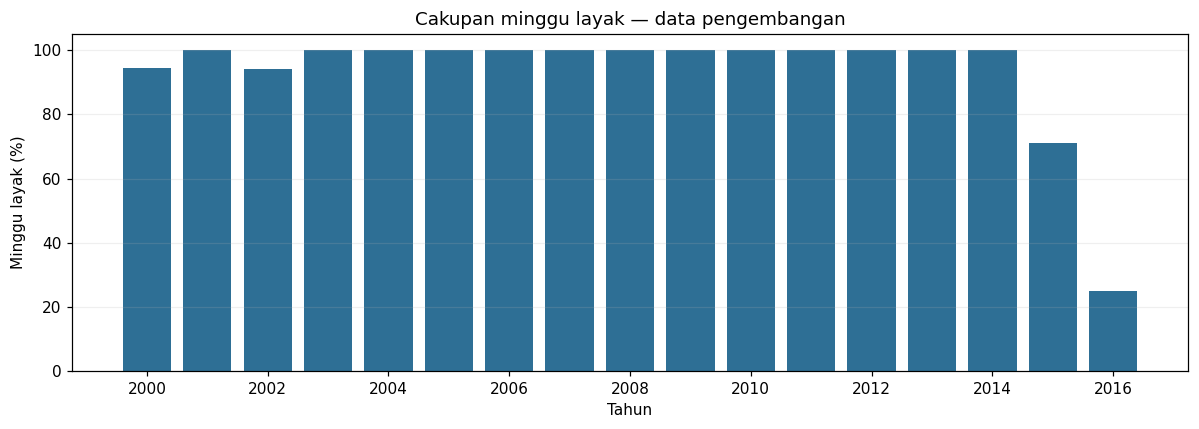

In [3]:
kelengkapan_tahunan = eda.groupby(eda.index.year).agg(
    jumlah_minggu=("week_valid", "size"),
    minggu_layak=("week_valid", "sum"),
    rata_hari_head=("head_obs_count", "mean")
)
kelengkapan_tahunan.index.name = "tahun"
kelengkapan_tahunan["minggu_tidak_layak"] = (
    kelengkapan_tahunan["jumlah_minggu"] - kelengkapan_tahunan["minggu_layak"]
)
kelengkapan_tahunan["persen_layak"] = (
    100 * kelengkapan_tahunan["minggu_layak"] / kelengkapan_tahunan["jumlah_minggu"]
)
display(kelengkapan_tahunan.round(2))

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(kelengkapan_tahunan.index, kelengkapan_tahunan["persen_layak"], color="#2E6F95")
ax.set(title="Cakupan minggu layak — data pengembangan",
       xlabel="Tahun", ylabel="Minggu layak (%)", ylim=(0, 105))
ax.set_xticks(kelengkapan_tahunan.index[::2])
ax.grid(axis="y", alpha=.2)
tampilkan_grafik(fig, "01_kelengkapan_tahunan.png")


**Cara membacanya:** batang yang lebih pendek menunjukkan cakupan lebih rendah, bukan head yang lebih rendah. Jika tahun 2015–2016 terlihat berbeda, cek kembali celah pengamatan yang sudah ditemukan pada notebook pertama. Jangan menganggap kekosongan tersebut sebagai musim kering atau penurunan head.

## 5. Membaca Perubahan dari Waktu ke Waktu

Saya menampilkan head, hujan, dan evaporasi potensial dalam panel terpisah karena satuannya berbeda. Posisi waktunya dibuat sama agar perubahan antarvariabel lebih mudah dibandingkan.

Head adalah rata-rata mingguan, sedangkan hujan dan evaporasi adalah total mingguan. Garis head yang terputus menunjukkan tidak ada nilai yang layak; saya tidak menghubungkan kedua ujung celah dengan interpolasi.


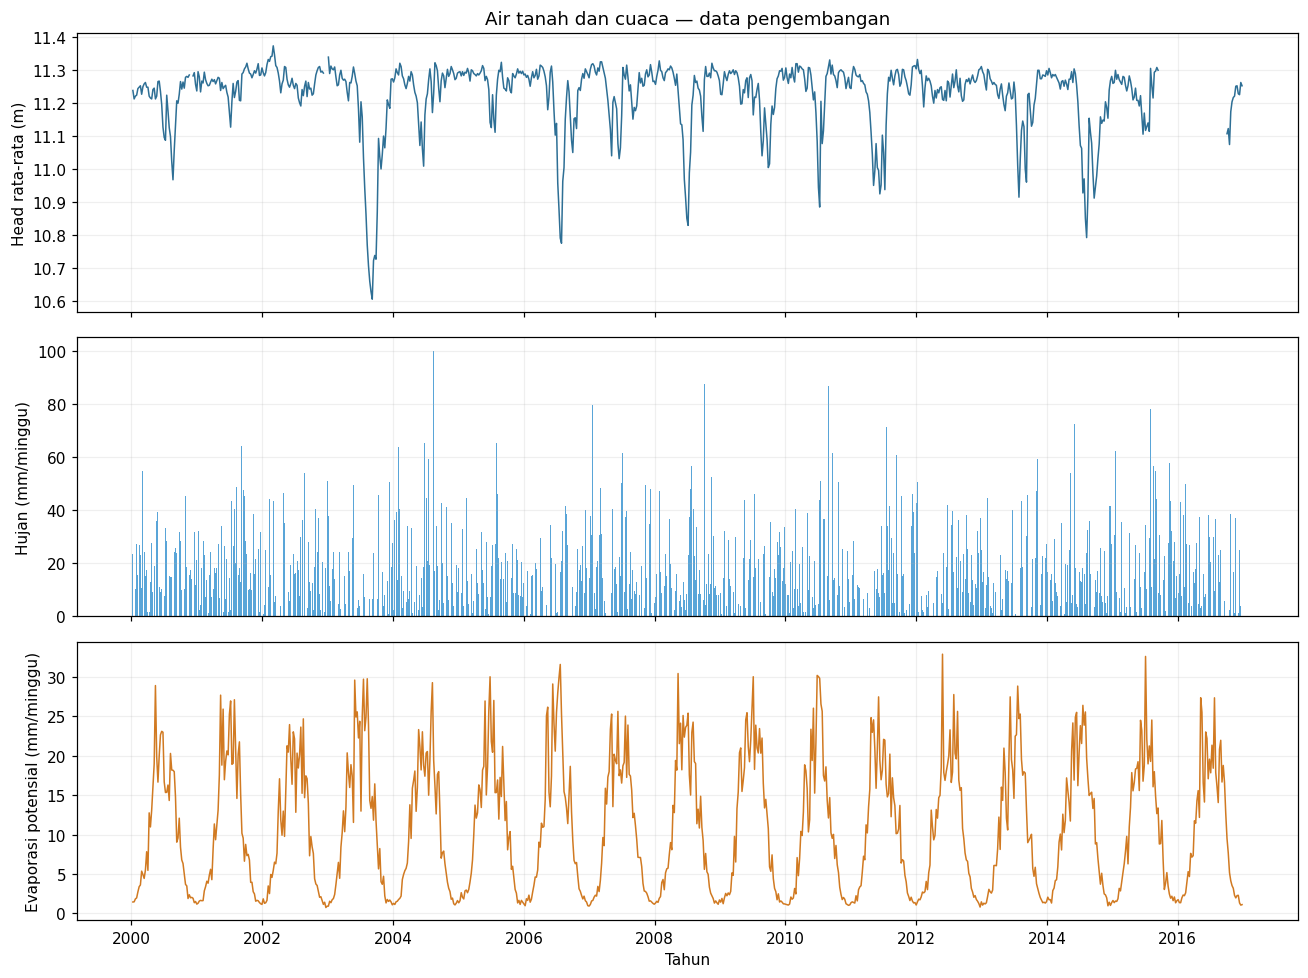

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(eda.index, eda["groundwater_head_m"], color="#2E6F95", linewidth=1)
axes[0].set(title="Air tanah dan cuaca — data pengembangan", ylabel="Head rata-rata (m)")
axes[1].bar(eda.index, eda["rainfall_mm"], width=5, color="#59A5D8")
axes[1].set_ylabel("Hujan (mm/minggu)")
axes[2].plot(eda.index, eda["potential_evaporation_mm"], color="#D17A22", linewidth=1)
axes[2].set(ylabel="Evaporasi potensial (mm/minggu)", xlabel="Tahun")
for ax in axes:
    ax.grid(alpha=.2)
tampilkan_grafik(fig, "02_deret_waktu.png")


**Yang ingin saya perhatikan:** apakah perubahan head tampak berulang, apakah ada periode penurunan yang panjang, dan apakah waktunya berdekatan dengan perubahan cuaca. Kemiripan visual masih berupa dugaan. Respons air tanah bisa tertunda, dan pola bersama dapat dipengaruhi musim atau variabel lain yang belum tersedia.

Grafik ini juga belum menunjukkan kemampuan prediksi. Menjelaskan kejadian yang sudah terlihat berbeda dengan memperkirakan minggu yang belum diamati.

## 6. Distribusi Nilai dan Perubahan Head

### 6.1 Statistik dan histogram

Ringkasan berikut memakai minggu layak agar variabel dibandingkan pada kumpulan minggu yang sama. Saya memeriksa rentang nilai, median, dan sebarannya. Histogram menunjukkan seberapa sering nilai muncul dalam suatu rentang; histogram tidak mempertahankan urutan waktu.

Nilai ekstrem belum tentu salah. Saya tidak menghapus nilai secara otomatis hanya karena posisinya jauh dari rata-rata.


,count,mean,std,min,25%,50%,75%,max
groundwater_head_m,827.0,11.226,0.106,10.604,11.210,11.261,11.287,11.374
rainfall_mm,827.0,17.074,15.724,0.000,4.800,13.700,24.550,100.000
temperature_mean_c,827.0,9.932,5.923,-7.206,5.489,10.103,14.801,22.747
relative_humidity_pct,827.0,83.652,6.589,54.957,79.801,84.757,88.664,94.042
potential_evaporation_mm,827.0,10.816,8.300,0.796,2.744,9.499,17.532,32.884


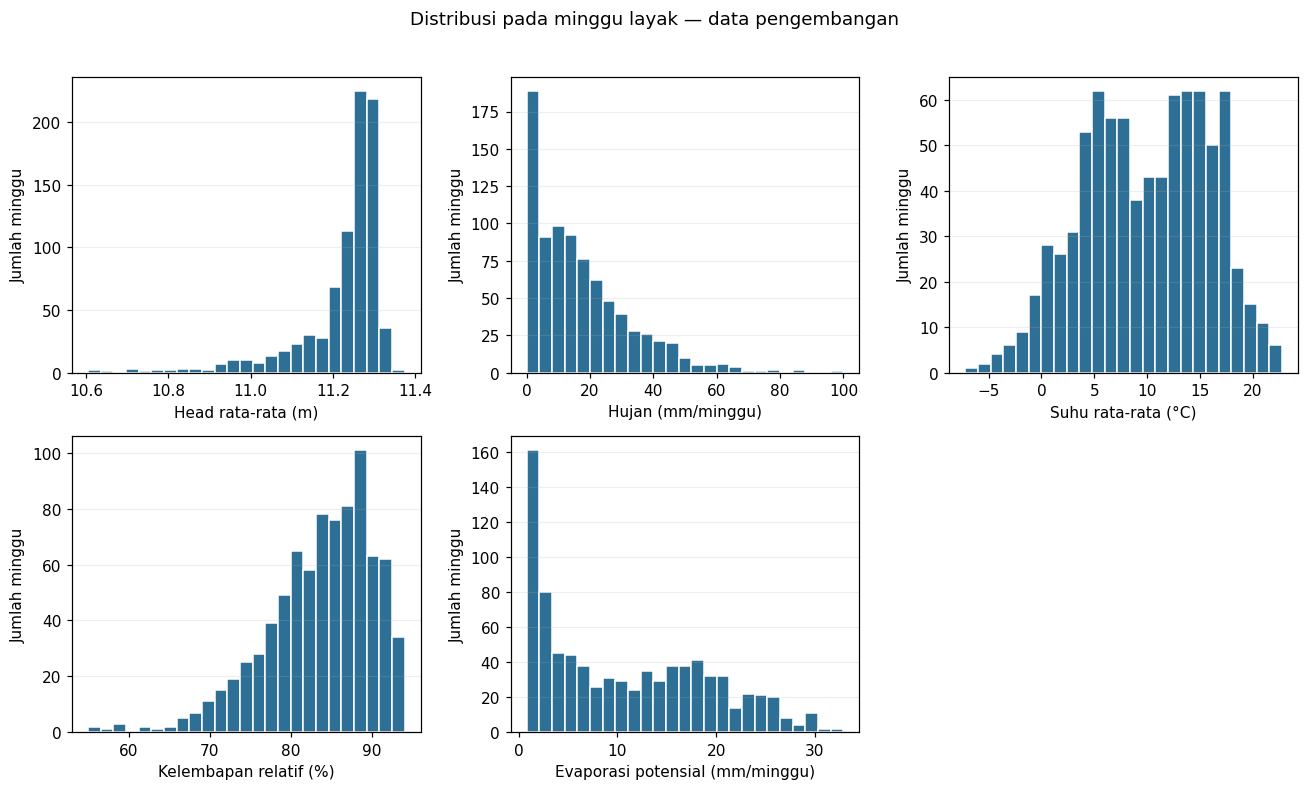

In [5]:
kolom_utama = ["groundwater_head_m", "rainfall_mm", "temperature_mean_c",
               "relative_humidity_pct", "potential_evaporation_mm"]
eda_layak = eda.loc[eda["week_valid"], kolom_utama].copy()
statistik = eda_layak.describe().T
display(statistik.round(3))

label = {
    "groundwater_head_m": "Head rata-rata (m)",
    "rainfall_mm": "Hujan (mm/minggu)",
    "temperature_mean_c": "Suhu rata-rata (°C)",
    "relative_humidity_pct": "Kelembapan relatif (%)",
    "potential_evaporation_mm": "Evaporasi potensial (mm/minggu)"
}
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, kolom in zip(axes.flat, kolom_utama):
    ax.hist(eda_layak[kolom].dropna(), bins=25, color="#2E6F95", edgecolor="white")
    ax.set(xlabel=label[kolom], ylabel="Jumlah minggu")
    ax.grid(axis="y", alpha=.2)
axes.flat[-1].axis("off")
fig.suptitle("Distribusi pada minggu layak — data pengembangan", y=1.02)
tampilkan_grafik(fig, "03_distribusi.png")


### 6.2 Perubahan head antarpekan

Head absolut menjelaskan posisi muka air tanah. Selisih `head(t) − head(t−1)` menjelaskan kenaikan atau penurunan dari minggu sebelumnya. Positif berarti naik, negatif berarti turun.

Saya menghitung `diff()` pada kalender utuh. Jika salah satu dari dua minggu kosong, selisihnya juga kosong. Kalau baris kosong dibuang lebih dulu, selisih dua observasi yang terpisah berbulan-bulan bisa keliru dianggap perubahan satu minggu.


,head_m,head_sebelumnya_m,perubahan_head_m,besar_perubahan_m
date,,,,
2010-07-18,11.206,10.884,0.321,0.321
2013-09-15,11.226,10.960,0.266,0.266
2014-08-24,11.154,10.916,0.239,0.239
2003-10-12,11.093,10.869,0.224,0.224
2011-07-17,11.133,10.937,0.196,0.196
2015-08-02,11.306,11.114,0.191,0.191
2006-08-06,10.963,10.774,0.189,0.189
2006-07-09,10.957,11.139,-0.181,0.181
2007-05-13,11.203,11.040,0.163,0.163


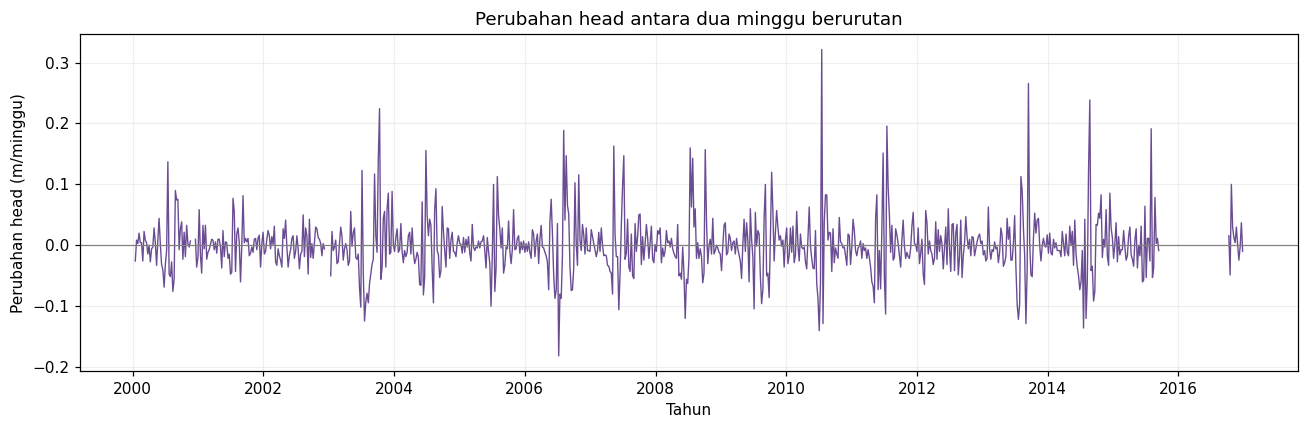

In [6]:
perubahan_head = eda["groundwater_head_m"].diff().rename("perubahan_head_m")
perubahan_terbesar = pd.DataFrame({
    "head_m": eda["groundwater_head_m"],
    "head_sebelumnya_m": eda["groundwater_head_m"].shift(1),
    "perubahan_head_m": perubahan_head
}).dropna()
perubahan_terbesar["besar_perubahan_m"] = perubahan_terbesar["perubahan_head_m"].abs()
perubahan_terbesar = perubahan_terbesar.nlargest(10, "besar_perubahan_m")
display(perubahan_terbesar.round(3))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(perubahan_head.index, perubahan_head, color="#6A4C93", linewidth=.9)
ax.axhline(0, color="grey", linewidth=.8)
ax.set(title="Perubahan head antara dua minggu berurutan",
       xlabel="Tahun", ylabel="Perubahan head (m/minggu)")
ax.grid(alpha=.2)
tampilkan_grafik(fig, "04_perubahan_head.png")


Tabel sepuluh perubahan terbesar adalah daftar untuk ditinjau, bukan daftar data yang harus dibuang. Untuk menyebut suatu lonjakan sebagai kesalahan pengukuran, saya masih membutuhkan pemeriksaan data harian atau informasi lapangan.

## 7. Apakah Ada Pola Musiman?

Saya mengelompokkan minggu berdasarkan **bulan pada tanggal akhir minggu**, lalu membandingkan distribusi head. Misalnya, minggu yang berakhir 2 Februari masuk kelompok Februari meskipun sebagian harinya ada di Januari.

Karena itu, ringkasan ini menggambarkan pola berdasarkan label minggu, bukan agregasi kalender bulanan yang presisi. Hujan pada tabel tetap merupakan rata-rata total **mingguan** dalam kelompok bulan, bukan total hujan bulanan.

Jumlah minggu tiap bulan juga ditampilkan karena celah pengamatan membuat cakupan tidak selalu seimbang.


,jumlah_minggu,median_head_m,rata_head_m,rata_hujan_mingguan_mm,rata_evaporasi_mingguan_mm
bulan,,,,,
1,69,11.287,11.283,18.425,1.541
2,65,11.283,11.283,16.172,2.999
3,71,11.276,11.280,12.749,6.860
4,69,11.259,11.251,9.338,13.729
5,70,11.243,11.224,15.471,19.002
6,69,11.213,11.178,14.254,21.310
7,71,11.161,11.133,23.772,21.708
8,71,11.230,11.161,24.861,18.602
9,67,11.226,11.176,16.837,12.359


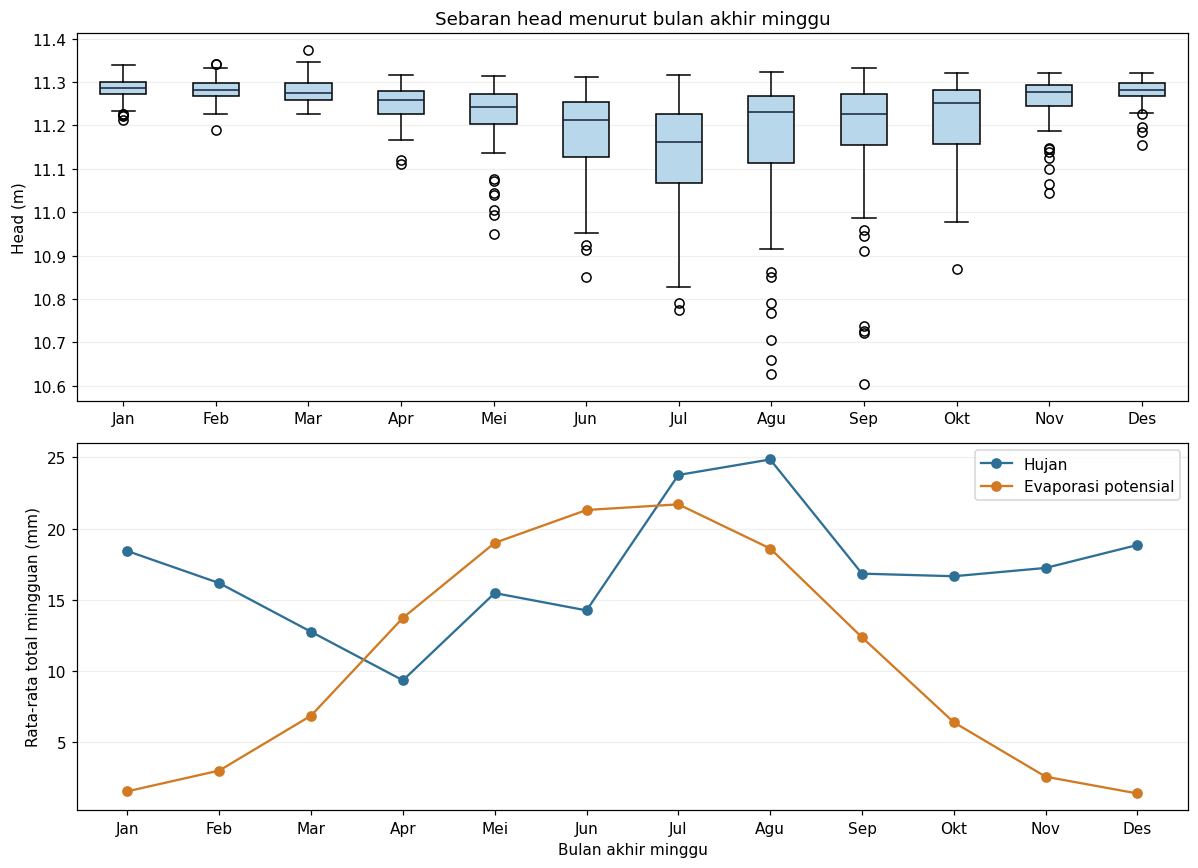

In [7]:
nama_bulan = ["Jan", "Feb", "Mar", "Apr", "Mei", "Jun",
              "Jul", "Agu", "Sep", "Okt", "Nov", "Des"]
kelompok_bulan = eda.loc[eda["week_valid"]].copy()
kelompok_bulan["bulan"] = kelompok_bulan.index.month
ringkasan_bulanan = kelompok_bulan.groupby("bulan").agg(
    jumlah_minggu=("groundwater_head_m", "count"),
    median_head_m=("groundwater_head_m", "median"),
    rata_head_m=("groundwater_head_m", "mean"),
    rata_hujan_mingguan_mm=("rainfall_mm", "mean"),
    rata_evaporasi_mingguan_mm=("potential_evaporation_mm", "mean")
).reindex(range(1, 13))
display(ringkasan_bulanan.round(3))

fig, axes = plt.subplots(2, 1, figsize=(11, 8))
nilai_bulanan = [
    kelompok_bulan.loc[kelompok_bulan["bulan"] == bulan, "groundwater_head_m"].to_numpy()
    for bulan in range(1, 13)
]
axes[0].boxplot(nilai_bulanan, patch_artist=True,
               boxprops={"facecolor": "#B9D7EA"},
               medianprops={"color": "#14213D"})
axes[0].set_xticks(range(1, 13), nama_bulan)
axes[0].set(title="Sebaran head menurut bulan akhir minggu", ylabel="Head (m)")
axes[1].plot(range(1, 13), ringkasan_bulanan["rata_hujan_mingguan_mm"],
             marker="o", label="Hujan", color="#2E6F95")
axes[1].plot(range(1, 13), ringkasan_bulanan["rata_evaporasi_mingguan_mm"],
             marker="o", label="Evaporasi potensial", color="#D17A22")
axes[1].set_xticks(range(1, 13), nama_bulan)
axes[1].set(ylabel="Rata-rata total mingguan (mm)", xlabel="Bulan akhir minggu")
axes[1].legend()
for ax in axes:
    ax.grid(axis="y", alpha=.2)
tampilkan_grafik(fig, "05_pola_musiman.png")


**Cara membaca boxplot:** garis di dalam kotak adalah median, sedangkan kotak mencakup 50% nilai tengah. Titik di luar whisker merupakan penanda statistik, bukan otomatis kesalahan sensor.

Jika median dan sebaran berbeda antarbulan, fitur musim layak dipertimbangkan. Namun, kita belum dapat menyatakan bahwa pola itu stabil di setiap tahun. Perbedaan jumlah pengamatan dan perubahan jangka panjang juga dapat memengaruhi ringkasan ini.

## 8. Hubungan Antarvariabel pada Minggu yang Sama

### 8.1 Korelasi linear

Korelasi Pearson berkisar dari −1 sampai +1. Nilai positif menunjukkan kecenderungan bergerak searah; nilai negatif menunjukkan kecenderungan berlawanan. Nilai mendekati nol berarti hubungan linearnya lemah, bukan berarti tidak ada hubungan dalam bentuk apa pun.

Tabel ini memakai minggu layak dengan seluruh variabel tersedia sehingga semua pasangan memakai observasi yang sama. Korelasi dihitung pada minggu yang sama dan **belum menjadi pengujian prediksi minggu berikutnya**.

Variabel cuaca dapat saling berkaitan, misalnya beberapa ukuran suhu. Hal ini menjadi alasan untuk mencoba regularisasi atau membandingkan kumpulan fitur yang lebih ringkas, bukan alasan untuk langsung membuang satu variabel tanpa validasi.


Jumlah minggu yang digunakan untuk semua pasangan: 827


,groundwater_head_m
rainfall_mm,0.133
temperature_mean_c,-0.460
temperature_min_c,-0.402
temperature_max_c,-0.484
sea_level_pressure_hpa,-0.107
relative_humidity_pct,0.335
wind_speed_ms,0.351
global_radiation_wm2,-0.416
potential_evaporation_mm,-0.452


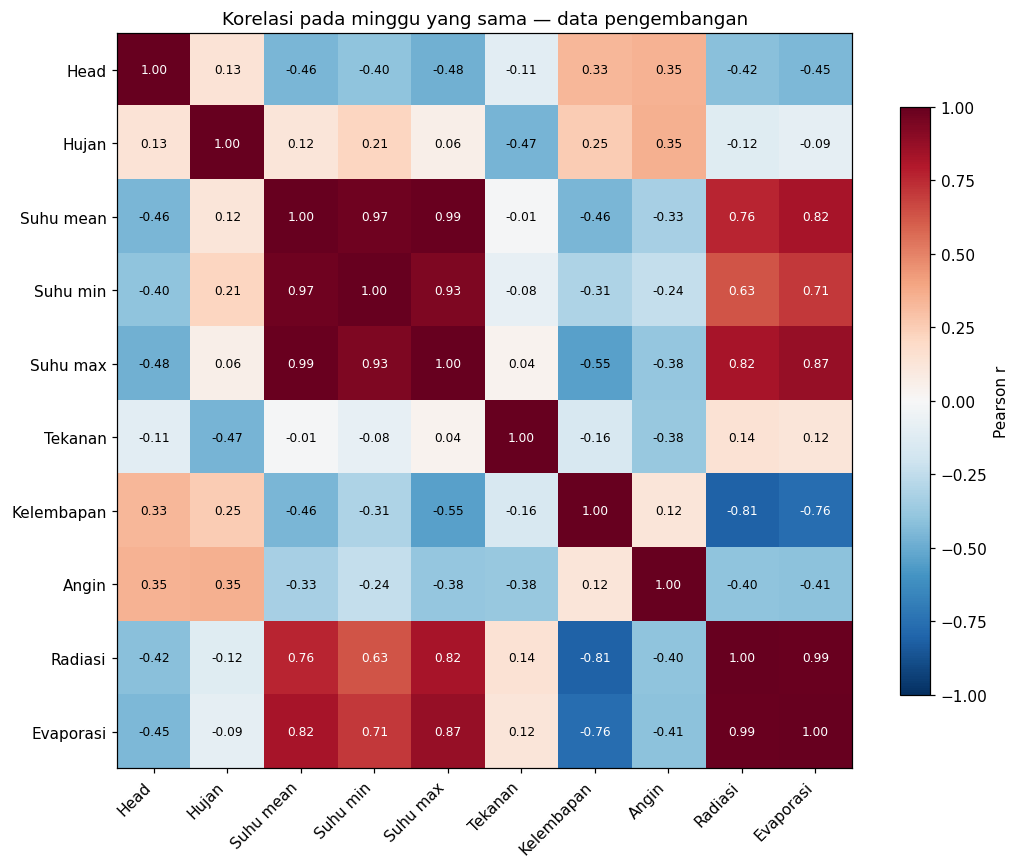

In [8]:
kolom_korelasi = ["groundwater_head_m", *kolom_cuaca]
data_korelasi = eda.loc[eda["week_valid"], kolom_korelasi].dropna()
korelasi = data_korelasi.corr(method="pearson")
print("Jumlah minggu yang digunakan untuk semua pasangan:", len(data_korelasi))
display(korelasi[["groundwater_head_m"]].drop(index="groundwater_head_m").round(3))

label_pendek = ["Head", "Hujan", "Suhu mean", "Suhu min", "Suhu max",
                "Tekanan", "Kelembapan", "Angin", "Radiasi", "Evaporasi"]
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(korelasi, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(label_pendek)), label_pendek, rotation=45, ha="right")
ax.set_yticks(range(len(label_pendek)), label_pendek)
for i in range(len(label_pendek)):
    for j in range(len(label_pendek)):
        nilai = korelasi.iloc[i, j]
        ax.text(j, i, f"{nilai:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(nilai) > .6 else "black")
ax.set_title("Korelasi pada minggu yang sama — data pengembangan")
fig.colorbar(im, ax=ax, shrink=.8, label="Pearson r")
tampilkan_grafik(fig, "06_korelasi.png")


### 8.2 Scatter plot sebagai pemeriksaan visual

Scatter plot membantu memeriksa apakah sebuah angka korelasi menyembunyikan pola melengkung, kumpulan titik, atau sebaran yang lebar. Setiap titik mewakili satu minggu layak. Saya membandingkan hujan serta evaporasi dengan head pada minggu yang sama.

Pola yang terlihat tidak membuktikan sebab-akibat. Musim, kondisi awal air tanah, dan faktor lokasi lain dapat berperan. Cuaca minggu ini juga mungkin lebih berkaitan dengan head pada minggu berikutnya; hal itu diperiksa setelah bagian ini.


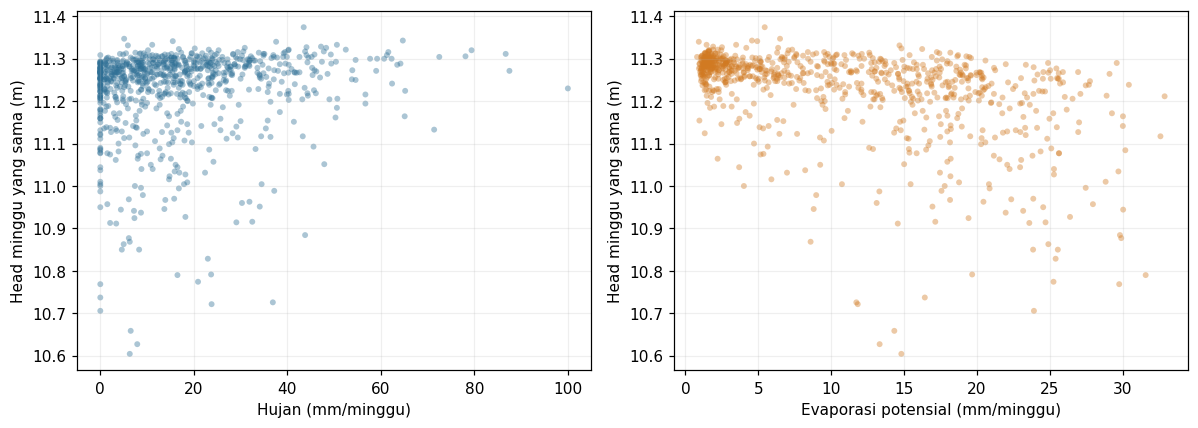

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, kolom, warna in zip(axes,
    ["rainfall_mm", "potential_evaporation_mm"], ["#2E6F95", "#D17A22"]):
    ax.scatter(data_korelasi[kolom], data_korelasi["groundwater_head_m"],
               s=15, alpha=.4, color=warna, edgecolors="none")
    ax.set(xlabel=label[kolom], ylabel="Head minggu yang sama (m)")
    ax.grid(alpha=.2)
tampilkan_grafik(fig, "07_scatter_cuaca_head.png")


## 9. Memeriksa Riwayat yang Berkaitan dengan Minggu Berikutnya

### 9.1 Menyiapkan target untuk eksplorasi

Saya membuat target sementara dengan `shift(-1)`: observasi minggu berikutnya diletakkan pada baris minggu saat prediksi dibuat. Pergeseran dilakukan pada kalender lengkap dan hanya dalam data pengembangan. Baris terakhir otomatis tidak mempunyai target; nilainya tidak diambil dari holdout.

Sebaliknya, `shift(k)` pada input mengambil nilai `k` minggu sebelum waktu prediksi. Untuk `k=0`, input berasal dari minggu saat ini, yang sudah selesai diamati. Dengan target `t+1`, hujan `t` sudah berjarak satu minggu dari target.

Pemeriksaan ini hanya mengeksplorasi hubungan, bukan melatih atau mengevaluasi model. Saya membandingkan input dengan dua besaran: head minggu berikutnya dan perubahan head menuju minggu berikutnya. Ini membantu membedakan hubungan dengan level air tanah dan hubungan dengan kenaikan/penurunannya.


,variabel,lag_minggu,target,jumlah_pasangan,pearson_r
0,groundwater_head_m,0,head_t_plus_1,823,0.900
1,groundwater_head_m,0,perubahan_t_ke_t_plus_1,823,-0.226
2,groundwater_head_m,1,head_t_plus_1,819,0.778
3,groundwater_head_m,1,perubahan_t_ke_t_plus_1,819,-0.272
4,groundwater_head_m,2,head_t_plus_1,816,0.685
5,groundwater_head_m,2,perubahan_t_ke_t_plus_1,815,-0.208
6,groundwater_head_m,4,head_t_plus_1,812,0.508
7,groundwater_head_m,4,perubahan_t_ke_t_plus_1,810,-0.194
8,groundwater_head_m,8,head_t_plus_1,804,0.227
9,groundwater_head_m,8,perubahan_t_ke_t_plus_1,802,-0.128


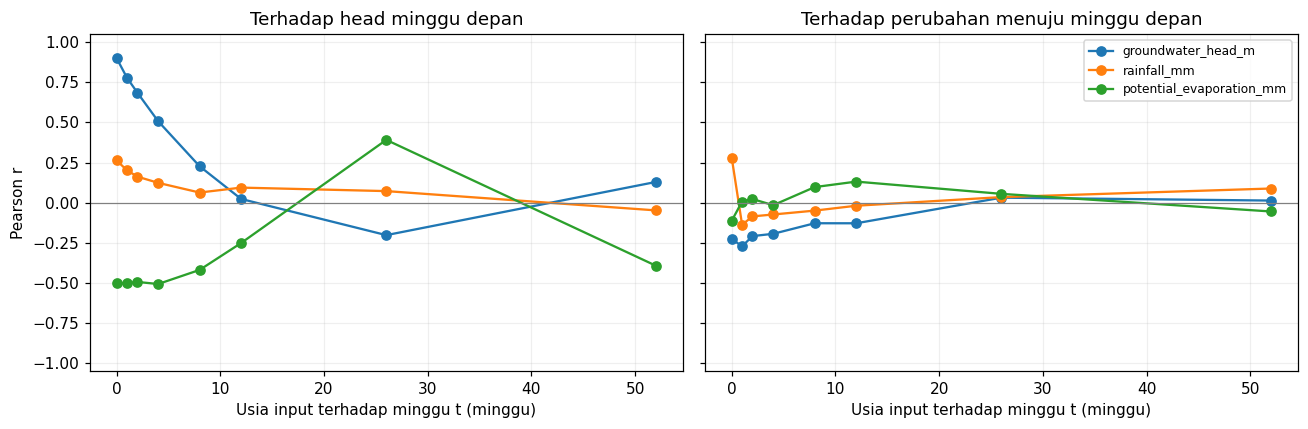

In [10]:
target_eda = eda["groundwater_head_m"].shift(-1).rename("head_minggu_depan_m")
perubahan_depan = (target_eda - eda["groundwater_head_m"]).rename("perubahan_minggu_depan_m")
tanggal_target = pd.Series(eda.index + pd.Timedelta(weeks=1), index=eda.index)
assert (tanggal_target.loc[target_eda.notna()] < BATAS_HOLDOUT).all()

# Angka lag menyatakan usia input terhadap minggu saat prediksi dibuat.
lag_diuji = [0, 1, 2, 4, 8, 12, 26, 52]
variabel_lag = ["groundwater_head_m", "rainfall_mm", "potential_evaporation_mm"]
rekaman_lag = []
for variabel in variabel_lag:
    for lag in lag_diuji:
        input_lag = eda[variabel].shift(lag)
        for nama_target, target in [("head_t_plus_1", target_eda),
                                     ("perubahan_t_ke_t_plus_1", perubahan_depan)]:
            pasangan = pd.concat([input_lag.rename("input"), target.rename("target")], axis=1).dropna()
            cukup = (len(pasangan) >= 3 and pasangan["input"].nunique() > 1
                     and pasangan["target"].nunique() > 1)
            nilai_r = pasangan["input"].corr(pasangan["target"]) if cukup else np.nan
            rekaman_lag.append({"variabel": variabel, "lag_minggu": lag,
                                 "target": nama_target, "jumlah_pasangan": len(pasangan),
                                 "pearson_r": nilai_r})
ringkasan_lag = pd.DataFrame(rekaman_lag)
display(ringkasan_lag.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, nama_target, judul in zip(axes,
    ["head_t_plus_1", "perubahan_t_ke_t_plus_1"],
    ["Terhadap head minggu depan", "Terhadap perubahan menuju minggu depan"]):
    for variabel in variabel_lag:
        bagian = ringkasan_lag.loc[(ringkasan_lag["variabel"] == variabel)
                                   & (ringkasan_lag["target"] == nama_target)]
        ax.plot(bagian["lag_minggu"], bagian["pearson_r"], marker="o", label=variabel)
    ax.axhline(0, color="grey", linewidth=.8)
    ax.set(title=judul, xlabel="Usia input terhadap minggu t (minggu)", ylim=(-1.05, 1.05))
    ax.grid(alpha=.2)
axes[0].set_ylabel("Pearson r")
axes[1].legend(fontsize=8)
tampilkan_grafik(fig, "08_hubungan_lag.png")


### 9.2 Batas interpretasi hasil lag

Jumlah pasangan dapat berbeda antar-lag karena awal periode dan celah pengamatan. Tabel menampilkan jumlahnya agar korelasi tidak dibandingkan seolah cakupannya identik. Pada pemodelan, perbandingan metode harus memakai tanggal evaluasi yang sama.

Korelasi head saat ini dengan head minggu depan dapat tinggi karena air tanah memiliki ketergantungan waktu. Ini justru membuat persistence penting sebagai pembanding: model rumit harus menunjukkan manfaat di atas perkiraan sederhana tersebut.

Lag dengan korelasi terbesar belum tentu merupakan waktu respons fisik akuifer. Musim, hubungan antarinput, dan korelasi serial dapat memengaruhinya. Untuk target perubahan, ingat bahwa `head(t)` juga menjadi bagian dari pengurangan `head(t+1) − head(t)`; korelasi negatif dengan head saat ini tidak langsung membuktikan mekanisme fisis.

Saya tidak mengambil p-value dari korelasi biasa sebagai bukti signifikansi karena observasi deret waktu tidak dapat dianggap saling bebas. EDA ini dipakai untuk menyusun kandidat, lalu manfaat prediksinya diuji lewat validasi waktu.


## 10. Ringkasan Temuan yang Dihitung dari Data

Kode berikut merangkum cakupan, rentang head, perbedaan median antarbulan, dan hubungan head minggu ini dengan minggu depan. Ringkasan dibuat otomatis agar narasi angka sesuai dengan file yang benar-benar dijalankan.

Perbedaan median bulanan bersifat deskriptif. Hasil ini belum membuktikan pola musiman yang stabil, dan korelasi satu pasangan lag belum membuktikan bahwa sebuah model akan akurat.


In [11]:
bulan_tersedia = ringkasan_bulanan["median_head_m"].dropna()
bulan_tinggi = int(bulan_tersedia.idxmax())
bulan_rendah = int(bulan_tersedia.idxmin())
pasangan_head = ringkasan_lag.loc[
    (ringkasan_lag["variabel"] == "groundwater_head_m")
    & (ringkasan_lag["lag_minggu"] == 0)
    & (ringkasan_lag["target"] == "head_t_plus_1")
].iloc[0]

catatan_temuan = [
    f"Data pengembangan mencakup {len(eda):,} minggu kalender; "
    f"{int(eda['week_valid'].sum()):,} minggu memenuhi aturan kelayakan.",
    f"Head pada minggu layak berkisar {eda_layak['groundwater_head_m'].min():.3f} "
    f"sampai {eda_layak['groundwater_head_m'].max():.3f} m terhadap acuan dataset.",
    f"Median head menurut bulan akhir minggu tertinggi pada {nama_bulan[bulan_tinggi-1]} "
    f"({bulan_tersedia.loc[bulan_tinggi]:.3f} m) dan terendah pada "
    f"{nama_bulan[bulan_rendah-1]} ({bulan_tersedia.loc[bulan_rendah]:.3f} m).",
    f"Korelasi head minggu t dengan t+1 adalah {pasangan_head['pearson_r']:.3f}, "
    f"dihitung dari {int(pasangan_head['jumlah_pasangan'])} pasangan tersedia.",
    "Temuan ini menjadi dasar kandidat fitur, bukan kesimpulan model terbaik."
]
for nomor, teks in enumerate(catatan_temuan, start=1):
    print(f"{nomor}. {teks}")


1. Data pengembangan mencakup 887 minggu kalender; 827 minggu memenuhi aturan kelayakan.
2. Head pada minggu layak berkisar 10.604 sampai 11.374 m terhadap acuan dataset.
3. Median head menurut bulan akhir minggu tertinggi pada Jan (11.287 m) dan terendah pada Jul (11.161 m).
4. Korelasi head minggu t dengan t+1 adalah 0.900, dihitung dari 823 pasangan tersedia.
5. Temuan ini menjadi dasar kandidat fitur, bukan kesimpulan model terbaik.


## 11. Menghubungkan EDA dengan Rencana Fitur

Saya membawa beberapa kandidat berikut ke tahap feature engineering. Daftar ini sengaja ringkas agar mudah dibandingkan. Tidak semua fitur harus masuk ke model akhir; keputusan itu ditentukan dari validasi pada data pengembangan.

| Kandidat | Alasan dicoba | Aturan agar tidak membaca masa depan |
| --- | --- | --- |
| Head minggu saat ini | Kondisi terakhir menjadi acuan persistence | Gunakan `head(t)` untuk memprediksi `head(t+1)` |
| Lag head 1, 2, dan 4 minggu | Menangkap riwayat kondisi sebelum minggu saat ini | Geser pada kalender lengkap |
| Rata-rata head 4 minggu | Merangkum kondisi terbaru | Jendela berakhir di `t`; butuh 4 minggu valid, tidak terpusat |
| Hujan dan evaporasi minggu ini | Kondisi cuaca terbaru mungkin memberi informasi tambahan | Tidak memakai cuaca aktual `t+1` |
| Total hujan/evaporasi 4 dan 8 minggu | Mencoba ringkasan kondisi beberapa minggu terakhir | Wajib jendela lengkap agar jumlah antarbaris sebanding |
| Suhu, kelembapan, dan cuaca lain | Kandidat tambahan untuk eksperimen | Scaling hanya dipelajari dari data latihan |
| Sinus–kosinus musim tahunan | Mewakili posisi dalam siklus tahun tanpa lompatan Desember–Januari | Gunakan kalender yang sudah diketahui, bukan statistik target holdout |

Rencana perbandingan fitur: **riwayat head saja → riwayat head + cuaca → tambahan fitur musim**. Kumpulan fitur dibandingkan pada tanggal evaluasi yang sama agar pengaruhnya dapat dinilai dengan adil.

EDA belum menjadi dasar untuk menghapus semua variabel dengan korelasi rendah. Model nonlinear mungkin menangkap hubungan yang tidak terlihat pada Pearson. Sebaliknya, korelasi tinggi juga bukan alasan otomatis memasukkan variabel yang tidak tersedia pada waktu prediksi operasional.

Pada tahap berikutnya, kalender tetap utuh saat membuat `shift()` dan `rolling()`. Pasangan yang input atau targetnya tidak memenuhi syarat baru disaring setelah fitur dibuat. Holdout terakhir tetap terpisah berdasarkan tanggal target, dan transformasi model hanya dipelajari pada fold latihan.


## 12. Menyimpan Dokumentasi EDA

Saya menyimpan tabel serta grafik agar bisa digunakan kembali saat menyusun laporan atau README. File konfigurasi mencatat batas holdout dan definisi horizon prediksi sehingga keputusan ini tidak berubah diam-diam di notebook pemodelan.

Data mentah dan CSV mingguan tidak ditulis ulang. Keluaran bagian ini adalah dokumentasi EDA, bukan dataset fitur yang sudah siap dilatih.


In [12]:
tabel_keluaran = {
    "ringkasan_pembagian.csv": ringkasan_pembagian,
    "kelengkapan_tahunan.csv": kelengkapan_tahunan.reset_index(),
    "statistik_minggu_layak.csv": statistik.reset_index().rename(columns={"index": "variabel"}),
    "ringkasan_bulanan.csv": ringkasan_bulanan.reset_index(),
    "korelasi_minggu_sama.csv": korelasi.reset_index().rename(columns={"index": "variabel"}),
    "hubungan_lag.csv": ringkasan_lag,
    "perubahan_head_terbesar.csv": perubahan_terbesar.reset_index()
}
for nama_file, tabel in tabel_keluaran.items():
    tabel.to_csv(OUTPUT_DIR / nama_file, index=False)

konfigurasi = {
    "sumber": "data/processed/netherlands_weekly.csv",
    "batas_holdout_tanggal_target": BATAS_HOLDOUT.strftime("%Y-%m-%d"),
    "frekuensi": "W-SUN",
    "horizon_minggu": 1,
    "target": "rata-rata hydraulic head pada minggu t+1",
    "batas_informasi": "akhir minggu t",
    "metrik_utama_rencana": "MAE",
    "catatan": "Pembagian model mengikuti tanggal target; preprocessing di-fit pada latihan tiap fold."
}
(OUTPUT_DIR / "konfigurasi_eksperimen.json").write_text(
    json.dumps(konfigurasi, ensure_ascii=False, indent=2), encoding="utf-8"
)
(OUTPUT_DIR / "ringkasan_temuan.txt").write_text(
    "\n".join(catatan_temuan), encoding="utf-8"
)
print("Selesai. Grafik, tabel, dan konfigurasi tersimpan di outputs/eda.")
print("Notebook berikutnya: 03_feature_engineering.ipynb.")


Selesai. Grafik, tabel, dan konfigurasi tersimpan di outputs/eda.
Notebook berikutnya: 03_feature_engineering.ipynb.


## 13. Kesimpulan dan Langkah Berikutnya

Melalui notebook ini, saya memisahkan periode pengembangan dari holdout sebelum mengeksplorasi pola untuk memilih fitur. Saya juga membedakan data yang cukup untuk menjelaskan cuaca dengan pasangan data yang cukup untuk menilai hubungan cuaca dan air tanah.

Hasil EDA berupa gambaran perubahan, sebaran, pola berdasarkan bulan, dan hubungan dengan jeda waktu. Temuan angka dapat dibaca pada bagian 10. Semua hubungan tersebut masih bersifat eksploratif; belum ada bukti bahwa satu algoritma lebih baik atau bahwa cuaca tertentu menyebabkan perubahan head secara langsung.

Langkah berikutnya adalah **feature engineering**: menyusun input historis, membuat target minggu depan, mencatat tanggal target, dan menghitung jumlah sampel yang benar-benar layak. Setelah itu, saya membandingkan persistence, seasonal naïve, dan model regresi yang sudah direncanakan dengan validasi berdasarkan waktu.

### Cek pemahaman

- **Mengapa holdout tidak ikut EDA pemilihan fitur?** Supaya keputusan fitur dan model tidak menyesuaikan diri dengan ujian terakhir.
- **Mengapa grafik tetap terputus pada gap?** Karena head yang tidak diamati tidak boleh disajikan seolah tersedia.
- **Mengapa korelasi tinggi belum menjamin prediksi bagus?** Karena korelasi menjelaskan hubungan pada data yang dilihat, sedangkan kemampuan prediksi perlu diuji pada waktu sesudahnya dan dibandingkan dengan baseline.
- **Mengapa baris kosong belum dibuang sebelum lag?** Supaya satu langkah tetap berarti satu minggu kalender.
- **Mengapa head saat ini dipakai sebagai baseline?** Karena kita perlu mengetahui apakah model memberi manfaat dibanding memakai kondisi terakhir sebagai perkiraan minggu depan.

### Sumber data proyek

- [Groundwater Time Series Modelling Challenge](https://github.com/gwmodeling/challenge)
- [Dokumentasi Netherlands](https://github.com/gwmodeling/challenge/blob/main/data/Netherlands/README.md)
- [Collenteur dkk. (2024)](https://doi.org/10.5194/hess-28-5193-2024)

Asal data dan kamus variabel dijelaskan lebih lengkap pada `01_data_understanding.ipynb`.
